---
title: "Statistical Testing"
---

In [43]:
import pandas as pd
import seaborn as sns
import numpy as np

from sklearn import preprocessing
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt
import math

import scipy.stats as stats
from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import chisquare
from scipy.stats import normaltest

from statsmodels.stats.proportion import proportions_ztest
import statsmodels.api as sm

In [44]:
lobster = pd.read_csv('lobster_run.csv')

In [45]:
lobster.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   userid          90189 non-null  int64  
 1   version         90189 non-null  object 
 2   sum_gamerounds  90189 non-null  int64  
 3   retention_1     90189 non-null  bool   
 4   retention_7     90189 non-null  bool   
 5   user_spend      90189 non-null  float64
dtypes: bool(2), float64(1), int64(2), object(1)
memory usage: 2.9+ MB


In [46]:
lobster.head(10)

,userid,version,sum_gamerounds,retention_1,retention_7,user_spend
0,1,Gulf of Maine,3,False,False,17.09
1,2,Gulf of Maine,38,True,False,15.30
2,7,Gulf of Maine,0,False,False,13.67
3,12,Gulf of Maine,0,False,False,16.92
4,14,Gulf of Maine,39,True,False,8.42
5,15,Gulf of Maine,305,True,False,16.54
6,16,Gulf of Maine,73,True,False,16.68
7,17,Gulf of Maine,14,True,False,8.79
8,18,Gulf of Maine,204,True,False,11.03
9,19,Gulf of Maine,108,True,True,13.05


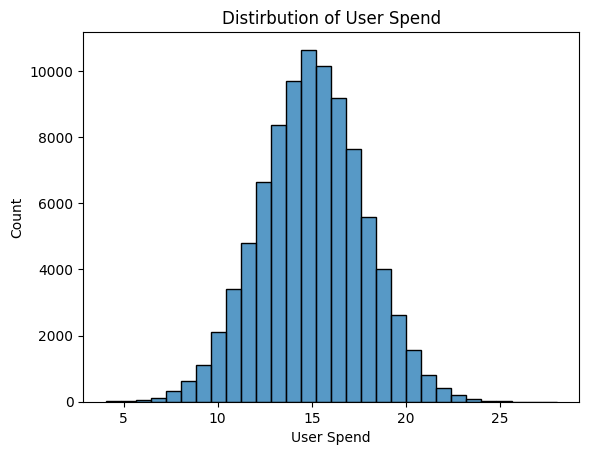

In [47]:

sns.histplot(lobster['user_spend'], bins = 30)
plt.title ("Distirbution of User Spend")
plt.xlabel("User Spend")
plt.ylabel("Count")
plt.show()


This plot of the user spend looks to have a reasonably normal distribution, ranging from around \$5 to \$25 dollars. The peak of users typically spend around \$15 dollars, with the middle 50% between \$12 and \$18.


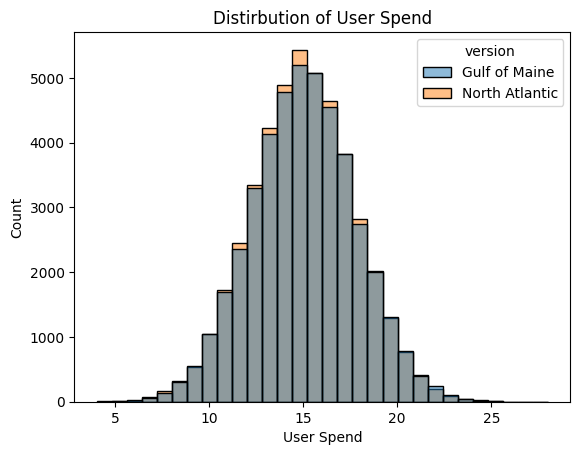

In [48]:

sns.histplot(data=lobster, x='user_spend', bins = 30, hue = 'version')
plt.title ("Distirbution of User Spend")
plt.xlabel("User Spend")
plt.ylabel("Count")
plt.show()

When adding the version as the a hue addition to the graph, we can see the that both sections have very similar distributions. The mains differences come through the bulk of the user spends between \$12 - \$18, where the north atlantic has slightly higher counts for various spend levels within that range. The only sections where the gulf of main has a higher count is around \$22 for user spend.

H0/Null Hypothesis: The user spend variable follows a normal distribution.


H1/Alternative Hypothesis: The user spend variable does not follow a normal distribution.


In [49]:
shapiro_test = shapiro(lobster['user_spend'])
print(f"Shapiro-Wilk test statistic: {shapiro_test.statistic}")
print(f"Shapiro-Wilk test p-value: {shapiro_test.pvalue}")

Shapiro-Wilk test statistic: 0.9999793688318734
Shapiro-Wilk test p-value: 0.9323343930781162


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 90189.
  res = hypotest_fun_out(*samples, **kwds)


In [50]:
# Random Sample with only 5000 datapoints, using shapiro
lobster_sample = lobster.sample(n=5000, random_state=42)
shapiro_test_sample = shapiro(lobster_sample['user_spend'])
print(f"Shapiro-Wilk test statistic (sample): {shapiro_test_sample.statistic}")
print(f"Shapiro-Wilk test p-value (sample): {shapiro_test_sample.pvalue}")

Shapiro-Wilk test statistic (sample): 0.9995899001854991
Shapiro-Wilk test p-value (sample): 0.3910419076137391


Test Statistic: 0.9996
P-Value: 0.3910

Based on these results and a significance level of 0.05, we fail to reject the null hypothesis. There is no significant evidence that demonstrates that the user spend variable deviates from a normal distribution.

I decided to do a shaprio normal distribution test with 5000 datapoints as the output said that the output may not be accurate for sample sizes greater than 5000.

H0/Null Hypothesis: There is no difference in difference in the means user spending between the Gulf of Maine and North Atlantic versions.

H1/Alternative Hypothesis: There is a difference in meaan user spending between the Gulf of Maine and North Atlantic versions.

In [51]:
gulf_of_maine_spend = lobster[lobster['version'] == 'Gulf of Maine']['user_spend']
north_atlantic_spend = lobster[lobster['version'] == 'North Atlantic']['user_spend']

ttest_result = ttest_ind(gulf_of_maine_spend, north_atlantic_spend)

print(f"T-test statistic: {ttest_result.statistic}")
print(f"T-test p-value: {ttest_result.pvalue}")

T-test statistic: 1.5874345137483725
T-test p-value: 0.11241777327832332


Based on these results and a significance level of 0.05, we fail to reject the null hypothesis. There is no significant evidence that demonstrates that the mean user spend variable is different between the Gulf of Maine and North Atlantic versions.

In [52]:
sumstat_version = lobster.groupby('version')['user_spend'].describe()
display(sumstat_version)

,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
Gulf of Maine,44700.0,15.030548,2.750119,4.50,13.17,15.03,16.89,26.55
North Atlantic,45489.0,15.001504,2.744418,4.05,13.16,15.00,16.85,28.00


These results show that the two versions are very similar. There is about ~800 more user count entries for North Atlantic and Gulf of Main. The means and medians are essentially the same, with a marginal difference of 0.03. Similarly, the standard deviations are essentially the same, with a difference of only 0.06. The range for the Gulf of Main ranges from 4.50-26.55, while the North Atlantic ranges from 4.05-28.00.

Based on these summary statistics, it is fair to infer that the version is not impacting user behavior.

H0/Null Hypothesis: The 1-day retention rate for users of the Gulf of Maine version is equal to the 1-day retention rate for users of the North Atlantic version.

H1/Alternative Hypothesis: There is a significant difference between the 1-day retention rate for users in the Gulf of Maine version and those in the North Atlantic version.

In [53]:
gulfofmaine = lobster[lobster['version'] == 'Gulf of Maine']
northatlantic  = lobster[lobster['version'] == 'North Atlantic']

In [54]:
gulf_of_maine_retention_1_count = gulfofmaine['retention_1'].sum()
north_atlantic_retention_1_count = northatlantic['retention_1'].sum()

print(f"Number of users in Gulf of Maine with retention_1: {gulf_of_maine_retention_1_count}")
print(f"Number of users in North Atlantic with retention_1: {north_atlantic_retention_1_count}")

Number of users in Gulf of Maine with retention_1: 20034
Number of users in North Atlantic with retention_1: 20119


In [55]:
gulf_of_maine_retention_1_rate = (gulfofmaine['retention_1'].sum() / len(gulfofmaine)) * 100
north_atlantic_retention_1_rate = (northatlantic['retention_1'].sum() / len(northatlantic)) * 100

print(f"Day 1 Retention Rate for Gulf of Maine: {gulf_of_maine_retention_1_rate:.2f}%")
print(f"Day 1 Retention Rate for North Atlantic: {north_atlantic_retention_1_rate:.2f}%")

Day 1 Retention Rate for Gulf of Maine: 44.82%
Day 1 Retention Rate for North Atlantic: 44.23%


In [56]:
totalgulf = len(gulfofmaine)
totalatlantic = len(northatlantic)
day1gulf = gulf_of_maine_retention_1_count
day1atlantic = north_atlantic_retention_1_count

p_day1 = (day1gulf + day1atlantic) / (totalgulf + totalatlantic)

expected_gulf_retained = totalgulf * p_day1
print(f"Expected retained (under H0): {expected_gulf_retained:.2f}")

Expected retained (under H0): 19900.86


The expected number of users from the Gulf of Maine version who stayed for 1 day is 19,900. I arrived at this value by calculating the overall retention rate from both versions and then multiplying it by the total number of Gulf of Maine users. This expected value represents the number of users we would anticipate being retained under the null hypothesis, where the version has no effect on 1-day retention.

In [57]:
overall_retention_1_rate = lobster['retention_1'].mean()

z_statistic, p_value = proportions_ztest(gulf_of_maine_retention_1_count, totalgulf, value=overall_retention_1_rate)

print(f"Binomial Z-test statistic for Gulf of Maine retention_1: {z_statistic}")
print(f"Binomial Z-test p-value for Gulf of Maine retention_1: {p_value}")

Binomial Z-test statistic for Gulf of Maine retention_1: 1.2662320258983257
Binomial Z-test p-value for Gulf of Maine retention_1: 0.20543002478527195


Since the p-value (0.205) is greater than the significance level (α = 0.05), we fail to reject the null hypothesis.

This indicates that there is no statistically significant difference between the Gulf of Maine version’s day-1 retention rate and the overall average retention rate.

H0/Null Hypothesis: The 7-day retention rate for users of the Gulf of Maine version is equal to the 7-day retention rate for users of the North Atlantic version.

H1/Alternative Hypothesis: There is a significant difference between the 7-day retention rate for users in the Gulf of Maine version and those in the North Atlantic version.

In [58]:
gulf_of_maine_retention_7_count = gulfofmaine['retention_7'].sum()
north_atlantic_retention_7_count = northatlantic['retention_7'].sum()

print(f"Number of users in Gulf of Maine with retention_7: {gulf_of_maine_retention_7_count}")
print(f"Number of users in North Atlantic with retention_7: {north_atlantic_retention_7_count}")

Number of users in Gulf of Maine with retention_7: 8744
Number of users in North Atlantic with retention_7: 8279


In [59]:
gulf_of_maine_retention_1_rate = (gulfofmaine['retention_7'].sum() / len(gulfofmaine)) * 100
north_atlantic_retention_1_rate = (northatlantic['retention_7'].sum() / len(northatlantic)) * 100

print(f"Day 7 Retention Rate for Gulf of Maine: {gulf_of_maine_retention_1_rate:.2f}%")
print(f"Day 7 Retention Rate for North Atlantic: {north_atlantic_retention_1_rate:.2f}%")

Day 7 Retention Rate for Gulf of Maine: 19.56%
Day 7 Retention Rate for North Atlantic: 18.20%


In [60]:
totalgulf = len(gulfofmaine)
totalatlantic = len(northatlantic)
day7gulf = gulf_of_maine_retention_7_count
day7atlantic = north_atlantic_retention_7_count

p_hat7 = (day7gulf + day7atlantic) / (totalgulf + totalatlantic)

expected_gulf_retained = totalgulf * p_hat7
print(f"Expected retained (under H0): {expected_gulf_retained:.2f}")

Expected retained (under H0): 8437.04


The expected number of users from the Gulf of Maine version who stayed for 7 days is 8,437. I arrived at this value by calculating the overall retention rate from both versions and then multiplying it by the total number of Gulf of Maine users. This expected value represents the number of users we would anticipate being retained under the null hypothesis, where the version has no effect on 7-day retention.

In [61]:
overall_retention_7_rate = lobster['retention_7'].mean()

z_statistic, p_value = proportions_ztest(gulf_of_maine_retention_7_count, totalgulf, value=overall_retention_7_rate)

print(f"Binomial Z-test statistic for Gulf of Maine retention_7: {z_statistic}")
print(f"Binomial Z-test p-value for Gulf of Maine retention_7: {p_value}")

Binomial Z-test statistic for Gulf of Maine retention_7: 3.66012876989815
Binomial Z-test p-value for Gulf of Maine retention_7: 0.0002520885313901679


Since the p-value (0.00025) is less than the significance level (α = 0.05), we reject the null hypothesis.

This indicates that there is a statistically significant difference between the Gulf of Maine version’s 7-day retention rate and the overall average retention rate.

In [62]:

avg_rounds_by_version = lobster.groupby('version')['sum_gamerounds'].mean()
print("Average game rounds by version:")
display(avg_rounds_by_version)

avg_rounds_by_version_retention_1 = lobster.groupby(['version', 'retention_1'])['sum_gamerounds'].mean()
print("\nAverage game rounds by version and Day 1 retention:")
display(avg_rounds_by_version_retention_1)

avg_rounds_by_version_retention_7 = lobster.groupby(['version', 'retention_7'])['sum_gamerounds'].mean()
print("\nAverage game rounds by version and Day 7 retention:")
display(avg_rounds_by_version_retention_7)

Average game rounds by version:


,sum_gamerounds
version,
Gulf of Maine,52.456264
North Atlantic,51.298776



Average game rounds by version and Day 1 retention:


version         retention_1
Gulf of Maine   False          18.379591
                True           94.411700
North Atlantic  False          16.340402
                True           95.381182
Name: sum_gamerounds, dtype: float64


Average game rounds by version and Day 7 retention:


version         retention_7
Gulf of Maine   False           52.578401
                True            51.954026
North Atlantic  False           25.856356
                True           165.649837
Name: sum_gamerounds, dtype: float64

In [63]:
print("\nSummary statistics for sum_gamerounds by version:")
display(lobster.groupby('version')['sum_gamerounds'].describe())

print("\nSummary statistics for sum_gamerounds by version and Day 1 retention:")
display(lobster.groupby(['version', 'retention_1'])['sum_gamerounds'].describe())

print("\nSummary statistics for sum_gamerounds by version and Day 7 retention:")
display(lobster.groupby(['version', 'retention_7'])['sum_gamerounds'].describe())


Summary statistics for sum_gamerounds by version:


,count,mean,std,min,25%,50%,75%,max
version,,,,,,,,
Gulf of Maine,44700.0,52.456264,256.716423,0.0,5.0,17.0,50.0,49854.0
North Atlantic,45489.0,51.298776,103.294416,0.0,5.0,16.0,52.0,2640.0



Summary statistics for sum_gamerounds by version and Day 1 retention:


count       mean         std  min   25%   50%  \
version        retention_1                                                    
Gulf of Maine  False        24666.0  18.379591  319.423232  0.0   2.0   6.0   
               True         20034.0  94.411700  135.037697  0.0  22.0  48.0   
North Atlantic False        25370.0  16.340402   35.925756  0.0   2.0   6.0   
               True         20119.0  95.381182  137.887256  0.0  21.0  49.0   

                              75%      max  
version        retention_1                  
Gulf of Maine  False         16.0  49854.0  
               True         111.0   2961.0  
North Atlantic False         16.0   1241.0  
               True         112.0   2640.0


Summary statistics for sum_gamerounds by version and Day 7 retention:


count        mean         std  min   25%    50%  \
version        retention_7                                                      
Gulf of Maine  False        35956.0   52.578401  281.836628  0.0   5.0   17.0   
               True          8744.0   51.954026  101.366855  0.0   5.0   17.0   
North Atlantic False        37210.0   25.856356   44.406112  0.0   4.0   11.0   
               True          8279.0  165.649837  183.792499  0.0  52.0  111.0   

                              75%      max  
version        retention_7                  
Gulf of Maine  False         50.0  49854.0  
               True          52.0   1544.0  
North Atlantic False         30.0   2640.0  
               True         211.0   2294.0

In [64]:
mean_spend_by_version = lobster.groupby('version')['user_spend'].mean()
print("Mean user spend by version:")
display(mean_spend_by_version)

mean_spend_by_version_retention_1 = lobster.groupby(['version', 'retention_1'])['user_spend'].mean()
print("\nMean user spend by version and Day 1 retention:")
display(mean_spend_by_version_retention_1)

mean_spend_by_version_retention_7 = lobster.groupby(['version', 'retention_7'])['user_spend'].mean()
print("\nMean user spend by version and Day 7 retention:")
display(mean_spend_by_version_retention_7)

Mean user spend by version:


,user_spend
version,
Gulf of Maine,15.030548
North Atlantic,15.001504



Mean user spend by version and Day 1 retention:


version         retention_1
Gulf of Maine   False          15.023092
                True           15.039728
North Atlantic  False          15.013641
                True           14.986199
Name: user_spend, dtype: float64


Mean user spend by version and Day 7 retention:


version         retention_7
Gulf of Maine   False          15.038002
                True           14.999897
North Atlantic  False          14.998053
                True           15.017013
Name: user_spend, dtype: float64

Based on the statistical results, there is no significant difference in 1-day retention between the two versions of the Super Lobster Run. This would suggest that the short term engagement within the first day is very similar. However, in comparison, there was a statistically significant difference in the 7-day retention between the two versions, that would indicate that the players in the Gulf of Maine version are more likely to remain engaged over a longer period.

From these results, we can see that for the users that are only retained for one day, the version makes little difference of their retention rate. This is may be because of their gaming habits or interest in gaming generally being lower, therefore they are less likely to be retained regardless, and version makes little difference. However, for those users who are more interested in gaming and take it more seriously/have more passiom, the version makes a bigger difference and therefore they are retained for longer on the version the deem to be better, creating the statistical difference between the 7 day retention for the two versions.

Based on some simple analysis of the mean spending breakdown by versions, and then by retention levels within the versions, there did not seem to be any significant difference between the spending levels. However, to compliment this analysis, I looked into the sum of game rounds per version, and rentention groups, and found something interesting. For the users who were retained for 7 days on the north atlantic version, they were playing sigificantly more rounds of the game, than those of the gulf of maine version. This is a baseline analysis and would require further examination to fully understand, but it does pose some interesting questions, despite having a lower retention rate. This may be beacuase the users play the game at a higher rate for the first 7 days, and then stop enjoying the game and therefore stop playing.

 Additional information that could be used to understand the results in context could include any additional payment options within the apps, the format of the game (ex. how is it played? is the users progress saved in one of the versions of the game? are there rewards for continuing to play over continous periods of time?), and the overall gaming quality/level of performance of the app. These additional pieces of information would help drive further insight into the users behvaviors and or why they interact differently for the 7 day retention between versions.

H0/Null Hypothesis: The observed distribution of visitor preferences matches the expected distribution given by park management. (30% Roller Coasters, 25% Water Rides, 15% for Restaurant, Exhibit and Shop)

H1/Alternative: The observed distribution of visitor preferences does not match the expected distribution.

Under the Null Hypothesis, the expected number of respondents are as follows:

Roller Coaster: 150

Water Rides: 125

Restaurant: 75

Marine Life: 75

Merchandise Shop: 75



In [65]:
expected_frequencies = {
    'Roller Coaster': 150.0,
    'Water Rides': 125.0,
    'Restaurant': 75.0,
    'Marine Life': 75.0,
    'Merchandise Shop': 75.0
}
print(expected_frequencies)

{'Roller Coaster': 150.0, 'Water Rides': 125.0, 'Restaurant': 75.0, 'Marine Life': 75.0, 'Merchandise Shop': 75.0}


In [66]:
observed_frequencies = np.array([150, 120, 90, 80, 60])
total_observations = np.sum(observed_frequencies)

expected_proportions = np.array([0.30, 0.25, 0.15, 0.15, 0.15])
expected_frequencies = expected_proportions * total_observations

chi2_statistic, p_value = chisquare(f_obs=observed_frequencies, f_exp=expected_frequencies)

print(f"Observed Frequencies: {observed_frequencies}")
print(f"Expected Frequencies: {expected_frequencies}")
print(f"Chi-square statistic: {chi2_statistic}")
print(f"P-value: {p_value}")

Observed Frequencies: [150 120  90  80  60]
Expected Frequencies: [150. 125.  75.  75.  75.]
Chi-square statistic: 6.533333333333333
P-value: 0.16270219326739285


Since the p-value (0.1627) is greater than the significance level (α = 0.05), we fail to reject the null hypothesis.

There is no statistically significant difference between the observed distribution of visitor preferences and the expected distribution proposed by park management.

In [67]:
(150 - 150)**2 / 150 + (120 - 125)**2 / 125 + (90 - 75)**2 / 75 + (80 - 75)**2 / 75 + (60 - 75)**2 / 75

6.533333333333333